# Modelado de Uplift con Inferencia Causal
## Hillstrom Email Campaign Dataset
---

## 1. Setup y Preparacion de Datos

En esta seccion cargamos las librerias necesarias y el dataset de Hillstrom. Creamos la variable de tratamiento (T) indicando si el cliente recibio un email y la variable de resultado (Y = conversion). Codificamos las caracteristicas categoricas y dividimos en entrenamiento y prueba (80/20) estratificando por tratamiento y outcome.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

import sys
sys.path.insert(0, '/home/tescobarr/Projects/uplift-modeling')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print("Librerias cargadas correctamente.")


Librerias cargadas correctamente.


In [2]:
# Cargar datos
df = pd.read_csv('/home/tescobarr/Projects/uplift-modeling/data/hillstrom.csv')
print(f"Dataset shape: {df.shape}")
print(f"Filas: {df.shape[0]:,}, Columnas: {df.shape[1]}")


Dataset shape: (64000, 12)
Filas: 64,000, Columnas: 12


In [3]:
# Crear variable de tratamiento T: 1 si recibio email (Mens o Womens), 0 si control
df['T'] = np.where(df['segment'] != 'No E-Mail', 1, 0)

# Variable de resultado Y: conversion binaria
df['Y'] = df['conversion'].values

print("Distribucion del tratamiento:")
print(df['T'].value_counts().to_string())
print(f"\nTasa de conversion general: {df['Y'].mean():.4f} ({df['Y'].mean()*100:.2f}%)")
print(f"\nConversion por grupo:")
print(df.groupby('T')['Y'].agg(['count', 'mean']).to_string())


Distribucion del tratamiento:
T
1    42694
0    21306

Tasa de conversion general: 0.0090 (0.90%)

Conversion por grupo:
   count      mean
T                 
0  21306  0.005726
1  42694  0.010681


In [4]:
# Definir columnas
numeric_features = ['recency', 'history', 'mens', 'womens', 'newbie']
# Nota: mens, womens, newbie ya son binarias (0/1), las dejamos como numericas

categorical_features = ['history_segment', 'zip_code', 'channel']

# Orden correcto para history_segment
hist_seg_order = [
    '1) $0 - $100',
    '2) $100 - $200',
    '3) $200 - $350',
    '4) $350 - $500',
    '5) $500 - $750',
    '6) $750 - $1,000',
    '7) $1,000 +'
]

# Preprocesador: Ordinal para history_segment, OneHot para zip_code y channel
preprocessor = ColumnTransformer(transformers=[
    ('hist_seg', OrdinalEncoder(categories=[hist_seg_order]), ['history_segment']),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), ['zip_code', 'channel']),
    ('num', 'passthrough', numeric_features)
])

print("Preprocesador definido.")
print(f"Caracteristicas numericas: {numeric_features}")
print(f"Caracteristicas categoricas: {categorical_features}")


Preprocesador definido.
Caracteristicas numericas: ['recency', 'history', 'mens', 'womens', 'newbie']
Caracteristicas categoricas: ['history_segment', 'zip_code', 'channel']


In [5]:
# Separar features, treatment, outcome
feature_cols = numeric_features + categorical_features
X_raw = df[numeric_features + categorical_features].copy()
T = df['T'].values
Y = df['Y'].values

# Division estratificada 80/20 por T+Y para mantener proporcion en ambos grupos
strata = T * 2 + Y  # 0: control no conv, 1: control conv, 2: treat no conv, 3: treat conv

X_train_raw, X_test_raw, T_train, T_test, Y_train, Y_test = train_test_split(
    X_raw, T, Y, test_size=0.2, random_state=42, stratify=strata
)

print(f"Train size: {X_train_raw.shape[0]:,}")
print(f"Test size:  {X_test_raw.shape[0]:,}")
print(f"\nDistribucion de tratamiento en train:\n{pd.Series(T_train).value_counts().to_string()}")
print(f"\nDistribucion de tratamiento en test:\n{pd.Series(T_test).value_counts().to_string()}")


Train size: 51,200
Test size:  12,800

Distribucion de tratamiento en train:
1    34155
0    17045

Distribucion de tratamiento en test:
1    8539
0    4261


In [6]:
# Ajustar preprocesador y transformar
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# Obtener nombres de columnas transformadas
cat_feat_names = (['history_segment_ord'] +
                  preprocessor.named_transformers_['cat'].get_feature_names_out(
                      ['zip_code', 'channel']).tolist())
all_feat_names = cat_feat_names + numeric_features

X_train_df = pd.DataFrame(X_train, columns=all_feat_names)
X_test_df = pd.DataFrame(X_test, columns=all_feat_names)

print(f"Dimensiones X_train: {X_train_df.shape}")
print(f"Dimensiones X_test:  {X_test_df.shape}")
print(f"\nCaracteristicas finales ({len(all_feat_names)}):")
print(all_feat_names)


Dimensiones X_train: (51200, 10)
Dimensiones X_test:  (12800, 10)

Caracteristicas finales (10):
['history_segment_ord', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web', 'recency', 'history', 'mens', 'womens', 'newbie']


## 2. S-Learner (Modelo Unico)

El S-Learner entrena un solo modelo de clasificacion que incluye el tratamiento como una caracteristica mas. Para predecir el uplift, calculamos:

$$\text{uplift}(x) = P(Y=1 \mid X=x, T=1) - P(Y=1 \mid X=x, T=0)$$

Implementacion manual: se anade T como feature, se entrena un solo clasificador, y se predice dos veces (con T=1 y T=0) para obtener el uplift.

In [7]:
# S-Learner: entrenar un solo modelo con T como feature
X_train_s = X_train_df.copy()
X_train_s['T'] = T_train

model_s = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    random_state=42, n_jobs=-1
)
model_s.fit(X_train_s, Y_train)
print("S-Learner (RandomForest) entrenado correctamente.")


S-Learner (RandomForest) entrenado correctamente.


In [8]:
# Predecir uplift: P(Y|X,T=1) - P(Y|X,T=0)
X_test_t1 = X_test_df.copy()
X_test_t1['T'] = 1
X_test_t0 = X_test_df.copy()
X_test_t0['T'] = 0

p_t1 = model_s.predict_proba(X_test_t1)[:, 1]
p_t0 = model_s.predict_proba(X_test_t0)[:, 1]
uplift_s = p_t1 - p_t0

print("=== S-Learner: Estadisticas de Uplift ===")
print(f"Media: {uplift_s.mean():.6f}")
print(f"Mediana: {np.median(uplift_s):.6f}")
print(f"Std: {uplift_s.std():.6f}")
print(f"Minimo: {uplift_s.min():.6f}")
print(f"Maximo: {uplift_s.max():.6f}")
print(f"% con uplift positivo: {(uplift_s > 0).mean() * 100:.2f}%")


=== S-Learner: Estadisticas de Uplift ===
Media: 0.003957
Mediana: 0.003408
Std: 0.004721
Minimo: -0.009816
Maximo: 0.029048
% con uplift positivo: 83.80%


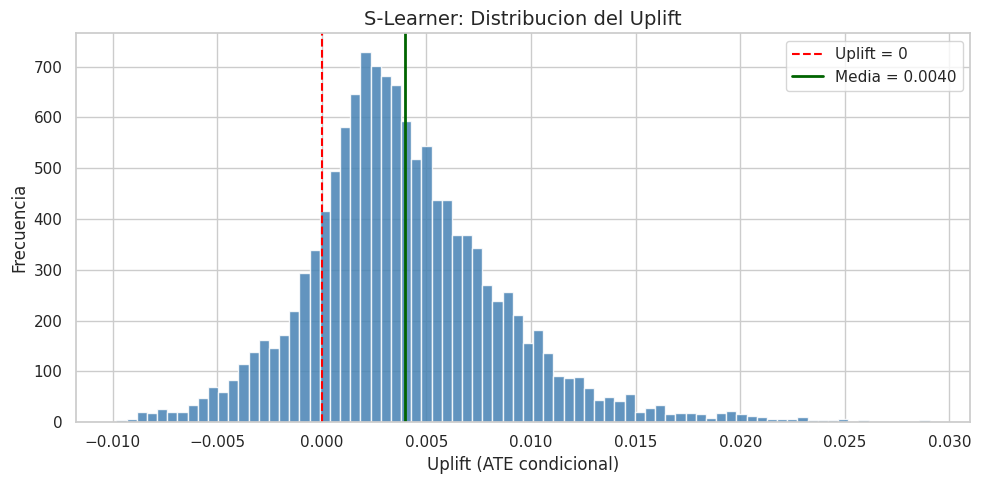

Histograma guardado.


In [9]:
# Histograma de uplift (S-Learner)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(uplift_s, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Uplift = 0')
ax.axvline(uplift_s.mean(), color='darkgreen', linestyle='-', linewidth=2,
           label=f'Media = {uplift_s.mean():.4f}')
ax.set_xlabel('Uplift (ATE condicional)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title('S-Learner: Distribucion del Uplift', fontsize=14)
ax.legend()
plt.tight_layout()
plt.savefig('/tmp/uplift_s_learner_dist.png', dpi=100)
plt.show()
print("Histograma guardado.")


## 3. T-Learner (Dos Modelos)

El T-Learner entrena dos modelos separados: uno para el grupo de tratamiento y otro para el grupo de control. El uplift es la diferencia de probabilidades entre ambos modelos:

$$\text{uplift}(x) = P(Y=1 \mid X=x, T=1) - P(Y=1 \mid X=x, T=0)$$

In [10]:
# T-Learner: modelos separados para tratamiento y control
mask_treat = T_train == 1
mask_ctrl = T_train == 0

model_treat = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    random_state=42, n_jobs=-1
)
model_control = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=50,
    random_state=42, n_jobs=-1
)

model_treat.fit(X_train_df.loc[mask_treat], Y_train[mask_treat])
model_control.fit(X_train_df.loc[mask_ctrl], Y_train[mask_ctrl])
print("T-Learner: ambos modelos entrenados correctamente.")
print(f"  Muestra de entrenamiento - Tratamiento: {mask_treat.sum():,}, Control: {mask_ctrl.sum():,}")


T-Learner: ambos modelos entrenados correctamente.
  Muestra de entrenamiento - Tratamiento: 34,155, Control: 17,045


In [11]:
# Predecir uplift
p_treat = model_treat.predict_proba(X_test_df)[:, 1]
p_ctrl = model_control.predict_proba(X_test_df)[:, 1]
uplift_t = p_treat - p_ctrl

print("=== T-Learner: Estadisticas de Uplift ===")
print(f"Media: {uplift_t.mean():.6f}")
print(f"Mediana: {np.median(uplift_t):.6f}")
print(f"Std: {uplift_t.std():.6f}")
print(f"Minimo: {uplift_t.min():.6f}")
print(f"Maximo: {uplift_t.max():.6f}")
print(f"% con uplift positivo: {(uplift_t > 0).mean() * 100:.2f}%")
print(f"\nProbabilidad base (control) media: {p_ctrl.mean():.6f}")
print(f"Probabilidad tratamiento media: {p_treat.mean():.6f}")


=== T-Learner: Estadisticas de Uplift ===
Media: 0.004922
Mediana: 0.004104
Std: 0.006794
Minimo: -0.019740
Maximo: 0.046062
% con uplift positivo: 80.97%

Probabilidad base (control) media: 0.005632
Probabilidad tratamiento media: 0.010554


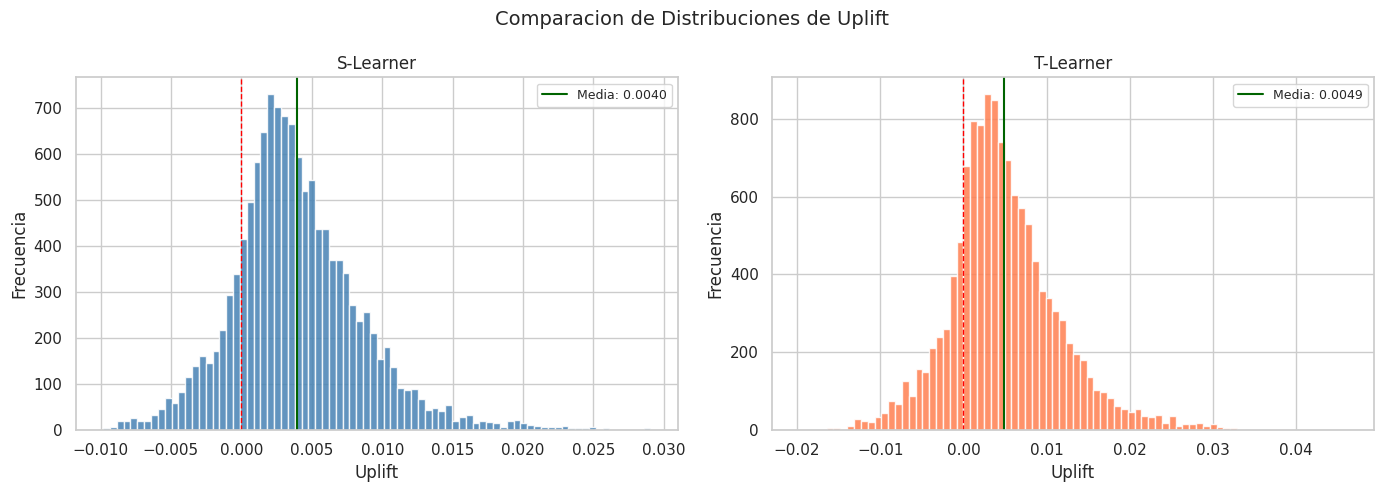

In [12]:
# Comparar distribuciones S-Learner vs T-Learner
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, uplift, title, color in zip(
    axes, [uplift_s, uplift_t],
    ['S-Learner', 'T-Learner'],
    ['steelblue', 'coral']
):
    ax.hist(uplift, bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.axvline(uplift.mean(), color='darkgreen', linestyle='-', linewidth=1.5,
               label=f'Media: {uplift.mean():.4f}')
    ax.set_xlabel('Uplift')
    ax.set_ylabel('Frecuencia')
    ax.set_title(title)
    ax.legend(fontsize=9)

plt.suptitle('Comparacion de Distribuciones de Uplift', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/uplift_comparison_hist.png', dpi=100)
plt.show()


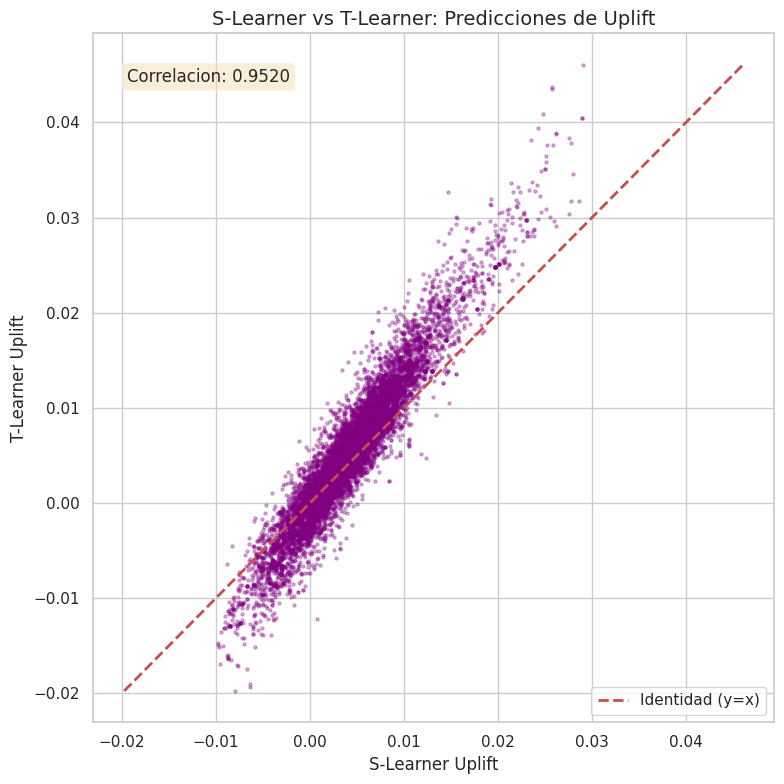

Correlacion entre S-Learner y T-Learner: 0.9520


In [13]:
# Scatter plot S-Learner vs T-Learner
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(uplift_s, uplift_t, alpha=0.3, s=5, c='purple')
lims = [min(uplift_s.min(), uplift_t.min()), max(uplift_s.max(), uplift_t.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Identidad (y=x)')
ax.set_xlabel('S-Learner Uplift', fontsize=12)
ax.set_ylabel('T-Learner Uplift', fontsize=12)
ax.set_title('S-Learner vs T-Learner: Predicciones de Uplift', fontsize=14)
ax.legend()
corr = np.corrcoef(uplift_s, uplift_t)[0, 1]
ax.text(0.05, 0.95, f'Correlacion: {corr:.4f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig('/tmp/uplift_scatter_s_vs_t.png', dpi=100)
plt.show()
print(f"Correlacion entre S-Learner y T-Learner: {corr:.4f}")


## 4. X-Learner (Aprendizaje Cruzado)

El X-Learner es particularmente efectivo cuando el outcome es desbalanceado (como en este caso, ~0.9% de conversion). Su enfoque de dos etapas:

1. Entrena modelos de tratamiento y control (como T-Learner)
2. Calcula los efectos individuales imputados (ITE) en cada grupo
3. Entrena modelos de segunda etapa para predecir los ITE
4. Combina las predicciones usando un modelo de propension


In [14]:
# --- X-Learner: Implementacion manual ---
# Etapa 1: Modelos de outcome (igual que T-Learner)
print("=== X-Learner ===")
print("Etapa 1: Entrenando modelos de tratamiento y control...")
m1 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50,
                            random_state=42, n_jobs=-1)
m0 = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50,
                            random_state=42, n_jobs=-1)

mask_t1 = T_train == 1
mask_t0 = T_train == 0

m1.fit(X_train_df.loc[mask_t1], Y_train[mask_t1])
m0.fit(X_train_df.loc[mask_t0], Y_train[mask_t0])
print("  Modelos entrenados.")

# Predicciones para ITE imputados
p1_train = m1.predict_proba(X_train_df)[:, 1]
p0_train = m0.predict_proba(X_train_df)[:, 1]

# ITE imputados para el grupo de tratamiento: Y_i - P(Y=0|X_i)
# ITE imputados para el grupo de control: P(Y=1|X_i) - Y_i
d_treat = Y_train[mask_t1] - p0_train[mask_t1]
d_ctrl = p1_train[mask_t0] - Y_train[mask_t0]

print(f"  ITE imputados - Tratamiento: media={d_treat.mean():.6f}, n={len(d_treat):,}")
print(f"  ITE imputados - Control: media={d_ctrl.mean():.6f}, n={len(d_ctrl):,}")


=== X-Learner ===
Etapa 1: Entrenando modelos de tratamiento y control...


  Modelos entrenados.
  ITE imputados - Tratamiento: media=0.004904, n=34,155
  ITE imputados - Control: media=0.004884, n=17,045


In [15]:
# Etapa 2: Modelos de segunda etapa para predecir ITE
print("Etapa 2: Entrenando modelos de segunda etapa...")
m2_treat = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50,
                                  random_state=42, n_jobs=-1)
m2_ctrl = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=50,
                                 random_state=42, n_jobs=-1)

# Convertir ITE a clases binarias (positivo/negativo) para clasificacion
# Usamos regresion indirecta: clasificamos si el ITE es > 0
d_treat_bin = (d_treat > 0).astype(int)
d_ctrl_bin = (d_ctrl > 0).astype(int)

m2_treat.fit(X_train_df.loc[mask_t1], d_treat_bin)
m2_ctrl.fit(X_train_df.loc[mask_t0], d_ctrl_bin)
print("  Modelos de segunda etapa entrenados.")

# Modelo de propension (LogisticRegression)
print("\nEntrenando modelo de propension...")
prop_model = LogisticRegression(max_iter=1000, random_state=42)
prop_model.fit(X_train_df, T_train)
prop_score = prop_model.predict_proba(X_train_df)[:, 1]  # P(T=1|X)
print("  Modelo de propension entrenado.")


Etapa 2: Entrenando modelos de segunda etapa...


  Modelos de segunda etapa entrenados.

Entrenando modelo de propension...


  Modelo de propension entrenado.


In [16]:
# Etapa 3: Combinar predicciones usando propension
# Para cada punto en test, predecimos uplift como:
#   uplift(x) = g(x) * tau_0(x) + (1 - g(x)) * tau_1(x)
# donde g(x) es la propension y tau son las predicciones de las segundas etapas

# Predicciones de segunda etapa (probabilidad de ITE positivo)
tau_1_test = m2_treat.predict_proba(X_test_df)[:, 1]  # Desde modelo treat
tau_0_test = m2_ctrl.predict_proba(X_test_df)[:, 1]  # Desde modelo control

# Propension en test
g_test = prop_model.predict_proba(X_test_df)[:, 1]

# Combinacion ponderada
uplift_x = g_test * tau_0_test + (1 - g_test) * tau_1_test

# Centrar alrededor del ATE
ate_estimate = Y_train[T_train == 1].mean() - Y_train[T_train == 0].mean()
uplift_x = uplift_x - uplift_x.mean() + ate_estimate

print("=== X-Learner: Estadisticas de Uplift ===")
print(f"Media: {uplift_x.mean():.6f}")
print(f"Mediana: {np.median(uplift_x):.6f}")
print(f"Std: {uplift_x.std():.6f}")
print(f"Minimo: {uplift_x.min():.6f}")
print(f"Maximo: {uplift_x.max():.6f}")
print(f"% con uplift positivo: {(uplift_x > 0).mean() * 100:.2f}%")


=== X-Learner: Estadisticas de Uplift ===
Media: 0.004937
Mediana: 0.004364
Std: 0.005489
Minimo: -0.013952
Maximo: 0.091630
% con uplift positivo: 85.84%


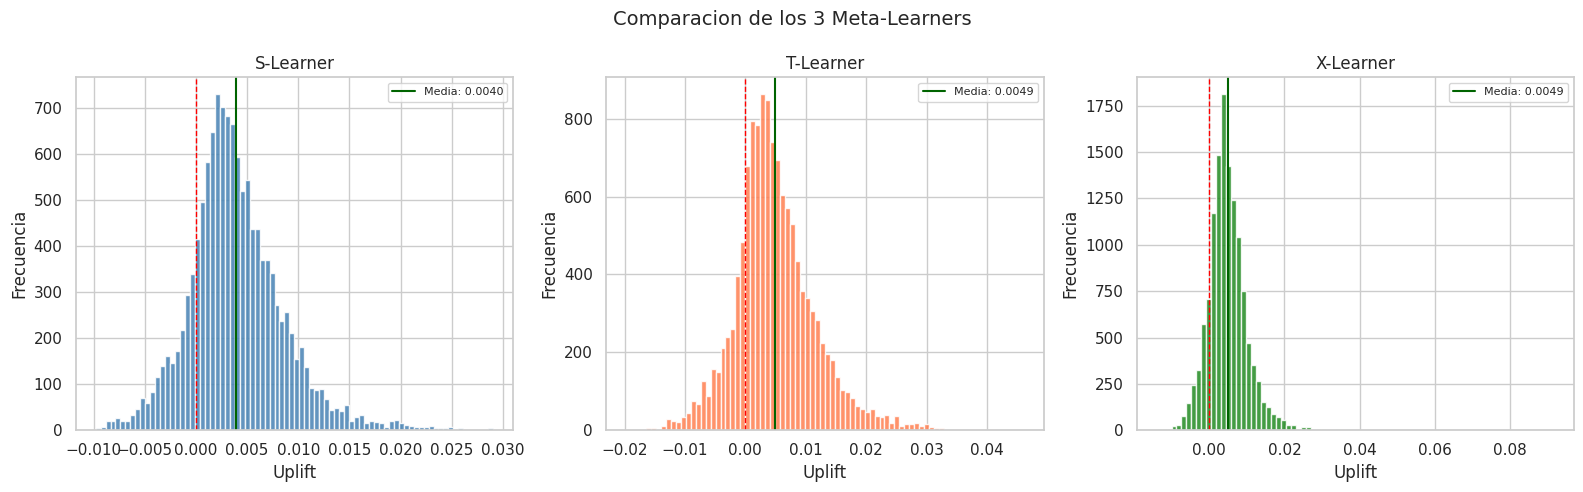

Distribuciones comparadas.


In [17]:
# Comparar distribuciones de los 3 modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, uplift, title, color in zip(
    axes, [uplift_s, uplift_t, uplift_x],
    ['S-Learner', 'T-Learner', 'X-Learner'],
    ['steelblue', 'coral', 'forestgreen']
):
    ax.hist(uplift, bins=80, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.axvline(uplift.mean(), color='darkgreen', linestyle='-', linewidth=1.5,
               label=f'Media: {uplift.mean():.4f}')
    ax.set_xlabel('Uplift')
    ax.set_ylabel('Frecuencia')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Comparacion de los 3 Meta-Learners', fontsize=14)
plt.tight_layout()
plt.savefig('/tmp/uplift_all_three.png', dpi=100)
plt.show()
print("Distribuciones comparadas.")


## 5. Evaluacion - Curva Qini y AUUC

La curva Qini mide el uplift incremental acumulado al ordenar a los clientes de mayor a menor uplift predicho. El AUUC (Area Under Uplift Curve) resume esta curva en un solo numero. La linea diagonal representa la seleccion aleatoria (random targeting).

In [18]:
def qini_curve(y_true, treatment, uplift_scores, n_bins=100):
    """
    Calcula la curva Qini.

    Parameters
    ----------
    y_true : array-like
        Variable de resultado (0/1)
    treatment : array-like
        Indicador de tratamiento (0/1)
    uplift_scores : array-like
        Scores de uplift predichos
    n_bins : int
        Numero de puntos en la curva

    Returns
    -------
    x : proporcion acumulada de la poblacion
    y : uplift incremental acumulado
    """
    idx = np.argsort(-uplift_scores)
    y_true_sorted = y_true[idx]
    treatment_sorted = treatment[idx]

    n = len(y_true_sorted)
    step = max(1, n // n_bins)

    x_vals = []
    y_vals = []

    for i in range(0, n + step, step):
        i = min(i, n)
        if i == 0:
            continue
        prop = i / n
        y_treat = y_true_sorted[:i][treatment_sorted[:i] == 1]
        y_control = y_true_sorted[:i][treatment_sorted[:i] == 0]

        rate_treat = y_treat.mean() if len(y_treat) > 0 else 0
        rate_control = y_control.mean() if len(y_control) > 0 else 0

        uplift_inc = rate_treat - rate_control
        x_vals.append(prop)
        y_vals.append(uplift_inc * i)

    return np.array(x_vals), np.array(y_vals)


def auuc_score(x_vals, y_vals):
    """Area bajo la curva de uplift (AUUC) usando regla del trapecio."""
    # numpy>=2 compat
    if hasattr(np, 'trapezoid'):
        return np.trapezoid(y_vals, x_vals)
    return np.trapz(y_vals, x_vals)


print("Funciones de evaluacion definidas.")


Funciones de evaluacion definidas.


In [19]:
# Calcular curvas Qini para los 3 modelos
x_s, y_s = qini_curve(Y_test, T_test, uplift_s)
x_t, y_t = qini_curve(Y_test, T_test, uplift_t)
x_x, y_x = qini_curve(Y_test, T_test, uplift_x)

# Linea aleatoria (random targeting)
ate = Y_test[T_test == 1].mean() - Y_test[T_test == 0].mean()
y_random = x_s * ate * len(Y_test)

print(f"ATE global en test: {ate:.6f}")
print("Curvas Qini calculadas para los 3 modelos.")


ATE global en test: 0.005025
Curvas Qini calculadas para los 3 modelos.


In [20]:
# Calcular AUUC
auuc_s = auuc_score(x_s, y_s)
auuc_t = auuc_score(x_t, y_t)
auuc_x = auuc_score(x_x, y_x)
auuc_rand = auuc_score(x_s, y_random)

print("=== Area Under Uplift Curve (AUUC) ===")
print(f"{'Modelo':<20} {'AUUC':<12} {'Mejora vs Random':<20}")
print("-" * 52)
print(f"{'S-Learner':<20} {auuc_s:<12.4f} {(auuc_s - auuc_rand):<20.4f}")
print(f"{'T-Learner':<20} {auuc_t:<12.4f} {(auuc_t - auuc_rand):<20.4f}")
print(f"{'X-Learner':<20} {auuc_x:<12.4f} {(auuc_x - auuc_rand):<20.4f}")
print(f"{'Random':<20} {auuc_rand:<12.4f} {'--':<20}")
print()

mejor_modelo = ['S-Learner', 'T-Learner', 'X-Learner'][np.argmax([auuc_s, auuc_t, auuc_x])]
print(f"** Mejor modelo por AUUC: {mejor_modelo} **")


=== Area Under Uplift Curve (AUUC) ===
Modelo               AUUC         Mejora vs Random    
----------------------------------------------------
S-Learner            32.5678      0.4142              
T-Learner            35.8078      3.6542              
X-Learner            34.1442      1.9906              
Random               32.1536      --                  

** Mejor modelo por AUUC: T-Learner **


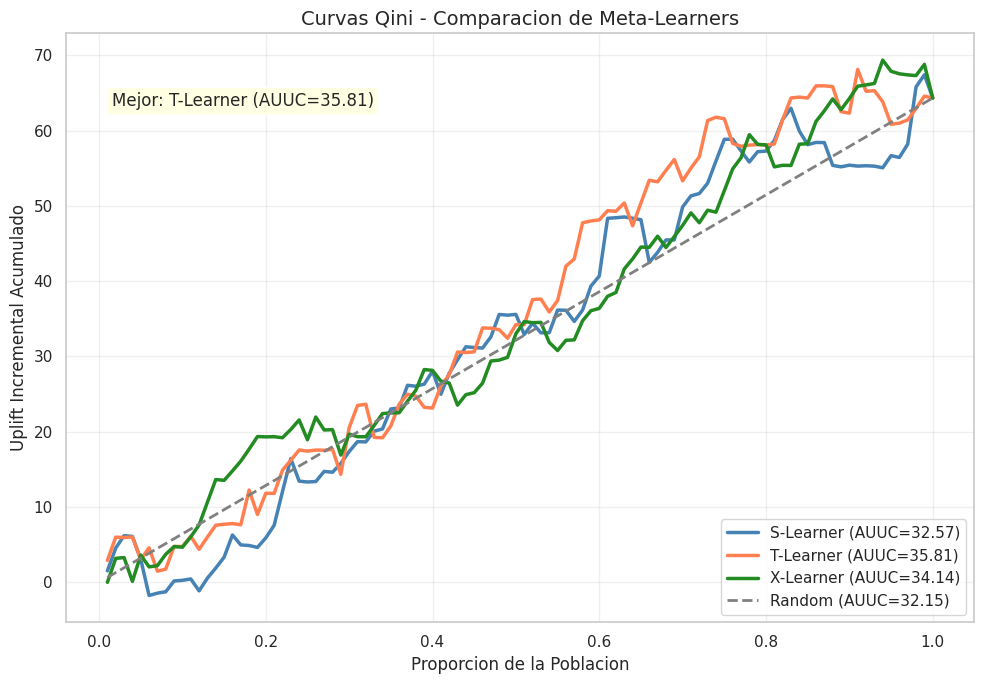

Curvas Qini graficadas correctamente.


In [21]:
# Graficar curvas Qini
fig, ax = plt.subplots(figsize=(10, 7))

ax.plot(x_s, y_s, linewidth=2.5, label=f'S-Learner (AUUC={auuc_s:.2f})', color='steelblue')
ax.plot(x_t, y_t, linewidth=2.5, label=f'T-Learner (AUUC={auuc_t:.2f})', color='coral')
ax.plot(x_x, y_x, linewidth=2.5, label=f'X-Learner (AUUC={auuc_x:.2f})', color='forestgreen')
ax.plot(x_s, y_random, '--', linewidth=2, label=f'Random (AUUC={auuc_rand:.2f})', color='gray')

ax.set_xlabel('Proporcion de la Poblacion', fontsize=12)
ax.set_ylabel('Uplift Incremental Acumulado', fontsize=12)
ax.set_title('Curvas Qini - Comparacion de Meta-Learners', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

mejor_nombre = ['S-Learner', 'T-Learner', 'X-Learner'][np.argmax([auuc_s, auuc_t, auuc_x])]
mejor_auuc = max(auuc_s, auuc_t, auuc_x)
ax.text(0.05, 0.9, f'Mejor: {mejor_nombre} (AUUC={mejor_auuc:.2f})',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.savefig('/tmp/qini_curves.png', dpi=100)
plt.show()
print("Curvas Qini graficadas correctamente.")


## 6. Segmentacion de Clientes - 4 Cuadrantes

Usamos el mejor modelo segun AUUC para clasificar a los clientes en 4 cuadrantes segun su uplift predicho y su probabilidad de conversion bajo control:

- **Persuadables**: Alto uplift - clientes que responden al tratamiento.
- **Sure Things**: Alta conversion incluso sin tratamiento - no necesitan el email.
- **Sleeping Dogs**: Uplift negativo - el tratamiento es contraproducente.
- **Lost Causes**: Baja probabilidad de conversion en cualquier caso.

In [22]:
# Seleccionar el mejor modelo
model_names = ['S-Learner', 'T-Learner', 'X-Learner']
auuc_values = [auuc_s, auuc_t, auuc_x]
best_idx = np.argmax(auuc_values)
best_name = model_names[best_idx]
print(f"Usando el mejor modelo: {best_name} (AUUC={auuc_values[best_idx]:.2f})")

models_uplift = {'S-Learner': uplift_s, 'T-Learner': uplift_t, 'X-Learner': uplift_x}
uplift_best = models_uplift[best_name]

# Probabilidad de conversion bajo control (del T-Learner)
p_control = model_control.predict_proba(X_test_df)[:, 1]

print(f"Uplift medio (mejor modelo): {uplift_best.mean():.6f}")
print(f"Probabilidad control media: {p_control.mean():.6f}")


Usando el mejor modelo: T-Learner (AUUC=35.81)
Uplift medio (mejor modelo): 0.004922
Probabilidad control media: 0.005632


In [23]:
# Clasificar en cuadrantes usando cuartiles
uplift_q = pd.qcut(uplift_best, 4, labels=False, duplicates='drop')
pcontrol_q = pd.qcut(p_control, 4, labels=False, duplicates='drop')

quadrant = np.full(len(uplift_best), 'Lost Causes', dtype=object)

# Persuadables: alto uplift (Q2-Q3) y medio-alta prob control (Q1-Q3)
pers_mask = (uplift_q >= 2) & (pcontrol_q >= 1)
quadrant[pers_mask] = 'Persuadables'

# Sure Things: bajo uplift (Q0-Q1) y alta prob control (Q2-Q3)
sure_mask = (uplift_q <= 1) & (pcontrol_q >= 2)
quadrant[sure_mask] = 'Sure Things'

# Sleeping Dogs: bajo uplift (Q0-Q1) y baja prob control (Q0-Q1)
sleep_mask = (uplift_q <= 1) & (pcontrol_q <= 1)
quadrant[sleep_mask] = 'Sleeping Dogs'

# Lost Causes: el resto (ya asignado por defecto)

print("\nDistribucion de cuadrantes:")
for q in ['Persuadables', 'Sure Things', 'Sleeping Dogs', 'Lost Causes']:
    cnt = (quadrant == q).sum()
    print(f"  {q:<20}: {cnt:>5} ({cnt/len(quadrant)*100:.1f}%)")



Distribucion de cuadrantes:
  Persuadables        :  4595 (35.9%)
  Sure Things         :  3639 (28.4%)
  Sleeping Dogs       :  2761 (21.6%)
  Lost Causes         :  1805 (14.1%)


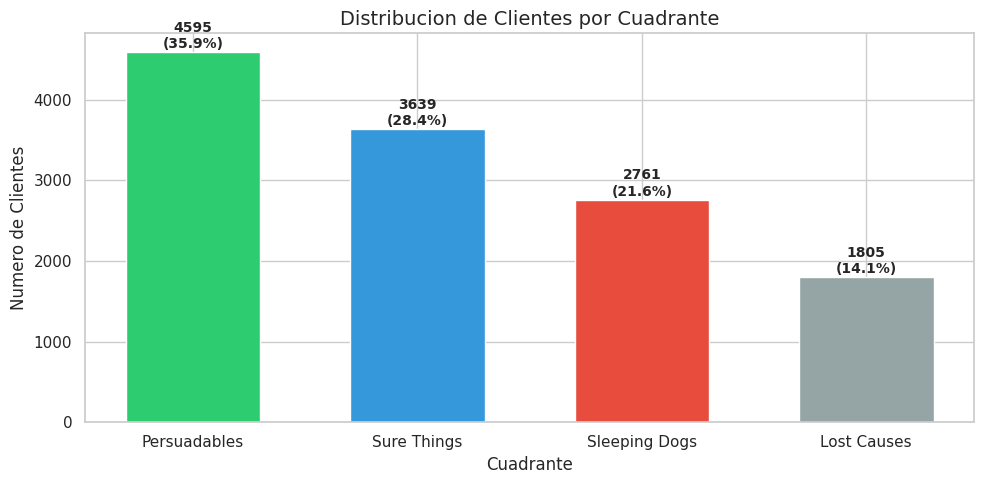

Distribucion de cuadrantes graficada.


In [24]:
# Anadir cuadrantes al dataframe de test
df_test = X_test_raw.copy()
df_test['uplift'] = uplift_best
df_test['p_control'] = p_control
df_test['quadrant'] = quadrant
df_test['T'] = T_test
df_test['Y'] = Y_test

# Grafico de barras
fig, ax = plt.subplots(figsize=(10, 5))
quadrant_counts = df_test['quadrant'].value_counts()
colors = {'Persuadables': '#2ecc71', 'Sure Things': '#3498db',
          'Sleeping Dogs': '#e74c3c', 'Lost Causes': '#95a5a6'}
bar_colors = [colors.get(q, '#95a5a6') for q in quadrant_counts.index]

bars = ax.bar(quadrant_counts.index, quadrant_counts.values,
              color=bar_colors, edgecolor='white', width=0.6)
ax.set_xlabel('Cuadrante', fontsize=12)
ax.set_ylabel('Numero de Clientes', fontsize=12)
ax.set_title('Distribucion de Clientes por Cuadrante', fontsize=14)

total = quadrant_counts.sum()
for bar, val in zip(bars, quadrant_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val}\n({val/total*100:.1f}%)', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('/tmp/quadrant_distribution.png', dpi=100)
plt.show()
print("Distribucion de cuadrantes graficada.")


In [25]:
# Perfil de cada cuadrante
print("=" * 70)
print("PERFIL DE CADA CUADRANTE")
print("=" * 70)

profile_cols = ['recency', 'history', 'mens', 'womens', 'newbie']

for q in ['Persuadables', 'Sure Things', 'Sleeping Dogs', 'Lost Causes']:
    subset = df_test[df_test['quadrant'] == q]
    print(f"\n{'=' * 60}")
    print(f"  CUADRANTE: {q}  (n={len(subset):,}, {len(subset)/len(df_test)*100:.1f}%)")
    print(f"{'=' * 60}")
    print(f"  Metricas numericas (media):")
    for col in profile_cols:
        print(f"    {col:<20}: {subset[col].mean():>8.2f}")
    print(f"    {'uplift':<20}: {subset['uplift'].mean():>8.6f}")
    print(f"    {'p_control':<20}: {subset['p_control'].mean():>8.6f}")
    print(f"    {'conversion rate':<20}: {subset['Y'].mean():>8.4f}")
    print(f"  Canal (top):")
    print(f"    {subset['channel'].value_counts().to_string()}")
    print(f"  history_segment (top 3):")
    for seg, cnt in subset['history_segment'].value_counts().head(3).items():
        print(f"    {seg:<25}: {cnt:>5} ({cnt/len(subset)*100:.1f}%)")


PERFIL DE CADA CUADRANTE

  CUADRANTE: Persuadables  (n=4,595, 35.9%)
  Metricas numericas (media):
    recency             :     4.92
    history             :   360.67
    mens                :     0.51
    womens              :     0.69
    newbie              :     0.55
    uplift              : 0.010327
    p_control           : 0.005984
    conversion rate     :   0.0098
  Canal (top):
    channel
Web             2022
Phone           1610
Multichannel     963
  history_segment (top 3):
    1) $0 - $100             :  1237 (26.9%)
    3) $200 - $350           :   891 (19.4%)
    5) $500 - $750           :   768 (16.7%)

  CUADRANTE: Sure Things  (n=3,639, 28.4%)
  Metricas numericas (media):
    recency             :     4.80
    history             :   239.16
    mens                :     0.52
    womens              :     0.56
    newbie              :     0.30
    uplift              : -0.001502
    p_control           : 0.010573
    conversion rate     :   0.0091
  Canal (top)

## 7. Conclusiones Clave

Resumen de los hallazgos del analisis de uplift modeling.

In [26]:
pers_percent = (quadrant == 'Persuadables').mean() * 100
sure_percent = (quadrant == 'Sure Things').mean() * 100
sleep_percent = (quadrant == 'Sleeping Dogs').mean() * 100
lost_percent = (quadrant == 'Lost Causes').mean() * 100

print("=" * 70)
print("CONCLUSIONES CLAVE - UPLIFT MODELING")
print("=" * 70)
print()
print("1. RENDIMIENTO DE MODELOS")
print("   ---------------------")
print(f"   S-Learner AUUC : {auuc_s:.2f}")
print(f"   T-Learner AUUC : {auuc_t:.2f}")
print(f"   X-Learner AUUC : {auuc_x:.2f}")
print(f"   Random   AUUC : {auuc_rand:.2f}")
print()
print(f"   Mejor modelo : {mejor_modelo} (AUUC = {max(auuc_s, auuc_t, auuc_x):.2f})")
print()
print("2. SEGMENTACION DE CLIENTES")
print("   ------------------------")
print(f"   Persuadables  : {pers_percent:.1f}% - Clientes que responden positivamente al email")
print(f"   Sure Things   : {sure_percent:.1f}% - Clientes que comprarian sin email")
print(f"   Sleeping Dogs : {sleep_percent:.1f}% - Clientes que responden negativamente al email")
print(f"   Lost Causes   : {lost_percent:.1f}% - Clientes con baja probabilidad de conversion")
print()
print("3. RECOMENDACIONES DE NEGOCIO")
print("   ---------------------------")
print(f"   - Dirigir la campania de email principalmente al segmento Persuadable")
print(f"     ({pers_percent:.1f}% de la base de clientes).")
print("   - NO enviar email a Sleeping Dogs ni Sure Things para evitar costos")
print("     innecesarios y posibles efectos negativos.")
print("   - Lost Causes requieren otras estrategias (descuentos agresivos,")
print("     re-engagement, etc.) fuera del email.")
print("   - El uplift model permite incrementar la eficiencia de la campania")
print("     evitando enviar emails a clientes que no los necesitan o que")
print("     responden negativamente.")
print()
print("=" * 70)
print("FIN DEL NOTEBOOK")
print("=" * 70)


CONCLUSIONES CLAVE - UPLIFT MODELING

1. RENDIMIENTO DE MODELOS
   ---------------------
   S-Learner AUUC : 32.57
   T-Learner AUUC : 35.81
   X-Learner AUUC : 34.14
   Random   AUUC : 32.15

   Mejor modelo : T-Learner (AUUC = 35.81)

2. SEGMENTACION DE CLIENTES
   ------------------------
   Persuadables  : 35.9% - Clientes que responden positivamente al email
   Sure Things   : 28.4% - Clientes que comprarian sin email
   Sleeping Dogs : 21.6% - Clientes que responden negativamente al email
   Lost Causes   : 14.1% - Clientes con baja probabilidad de conversion

3. RECOMENDACIONES DE NEGOCIO
   ---------------------------
   - Dirigir la campania de email principalmente al segmento Persuadable
     (35.9% de la base de clientes).
   - NO enviar email a Sleeping Dogs ni Sure Things para evitar costos
     innecesarios y posibles efectos negativos.
   - Lost Causes requieren otras estrategias (descuentos agresivos,
     re-engagement, etc.) fuera del email.
   - El uplift model permi